PART A : Data cleaning, Data preprocessing and EDA

In [1]:
# Installing and importing all libraries needed for processing and correct train/validation splitting

!pip install -q scikit-learn pandas numpy matplotlib seaborn

import io, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupShuffleSplit

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (12, 4)
sns.set_style('whitegrid')

print('✅ All libraries ready!')

✅ All libraries ready!


In [2]:
# Reading train and test CSV files directly

import pandas as pd

train_raw = pd.read_csv('train_data.csv')
test_raw  = pd.read_csv('test_data.csv')

print(f'✅ Train : {train_raw.shape[0]:,} rows × {train_raw.shape[1]} columns')
print(f'   Test  : {test_raw.shape[0]:,} rows × {test_raw.shape[1]} columns')

✅ Train : 162,634 rows × 103 columns
   Test  : 24,484 rows × 103 columns


In [3]:
# Printing shape, data types, and first few rows to understand the raw dataset

print(f'Train shape  : {train_raw.shape}')
print(f'Test  shape  : {test_raw.shape}')
print(f'Memory       : {train_raw.memory_usage(deep=True).sum()/1e6:.1f} MB')
print()
print('Data types:')
print(train_raw.dtypes.value_counts())
print()
train_raw.head(3)

Train shape  : (162634, 103)
Test  shape  : (24484, 103)
Memory       : 141.7 MB

Data types:
float64    98
int64       4
object      1
Name: count, dtype: int64



,event_id,time_to_tca,mission_id,risk,max_risk_estimate,max_risk_scaling,miss_distance,relative_speed,relative_position_r,relative_position_t,relative_position_n,relative_velocity_r,relative_velocity_t,relative_velocity_n,t_time_lastob_start,t_time_lastob_end,t_recommended_od_span,t_actual_od_span,t_obs_available,t_obs_used,t_residuals_accepted,t_weighted_rms,t_rcs_estimate,t_cd_area_over_mass,t_cr_area_over_mass,...,t_h_per,c_h_apo,c_h_per,geocentric_latitude,azimuth,elevation,mahalanobis_distance,t_position_covariance_det,c_position_covariance_det,t_sigma_r,c_sigma_r,t_sigma_t,c_sigma_t,t_sigma_n,c_sigma_n,t_sigma_rdot,c_sigma_rdot,t_sigma_tdot,c_sigma_tdot,t_sigma_ndot,c_sigma_ndot,F10,F3M,SSN,AP
0,0,1.5668,5,-10.2050,-7.8348,8.6021,14923.0000,13792.0000,453.8000,5976.6000,-13666.8000,-7.2000,-12637.0000,-5525.9000,1.0000,0.0000,3.7800,3.7800,459,458,98.9000,1.2650,0.4020,0.0138,0.0072,...,590.8183,650.4973,606.4434,-73.5741,-23.6188,0.0299,129.4310,737347.1252,44299229321068096.0000,4.0579,266.7223,137.6171,54366.8649,1.7814,46.6126,0.1474,58.2721,0.0041,0.1650,0.0030,0.3865,89.0000,83.0000,42.0000,11.0000
1,0,1.2075,5,-10.3558,-7.8489,8.9564,14544.0000,13792.0000,474.3000,5821.2000,-13319.8000,-7.0000,-12637.0000,-5525.9000,1.0000,0.0000,3.7900,3.7900,456,455,98.5000,1.2700,0.4020,0.0135,0.0091,...,590.8230,650.5133,606.4548,-73.5707,-23.6188,0.0291,271.5404,114138.9936,43786100432694320.0000,3.5268,262.1918,56.0701,54082.0673,1.8010,46.5959,0.0597,57.9664,0.0038,0.1644,0.0029,0.3864,89.0000,83.0000,42.0000,11.0000
2,0,0.9522,5,-10.3456,-7.8474,8.9322,14475.0000,13792.0000,474.6000,5796.2000,-13256.1000,-7.0000,-12637.0000,-5525.9000,1.0000,0.0000,3.7900,3.8000,456,455,98.5000,1.2570,0.4020,0.0134,0.0071,...,590.8215,650.5151,606.4580,-73.5701,-23.6188,0.0291,347.8993,46960.0411,43691053790246208.0000,3.3620,261.6665,37.4979,54027.3912,1.8219,46.5928,0.0393,57.9076,0.0036,0.1644,0.0030,0.3864,89.0000,83.0000,42.0000,11.0000


=== TARGET: risk ===
count   162634.0000
mean       -19.3406
std         10.0116
min        -30.0000
25%        -30.0000
50%        -17.8706
75%         -9.1733
max         -1.4429
Name: risk, dtype: float64

Rows at floor -30       : 67,240  (41.3%)
Rows with risk > -10    : 45,793  (28.2%)
Rows with risk > -5     : 3,381  (2.08%)


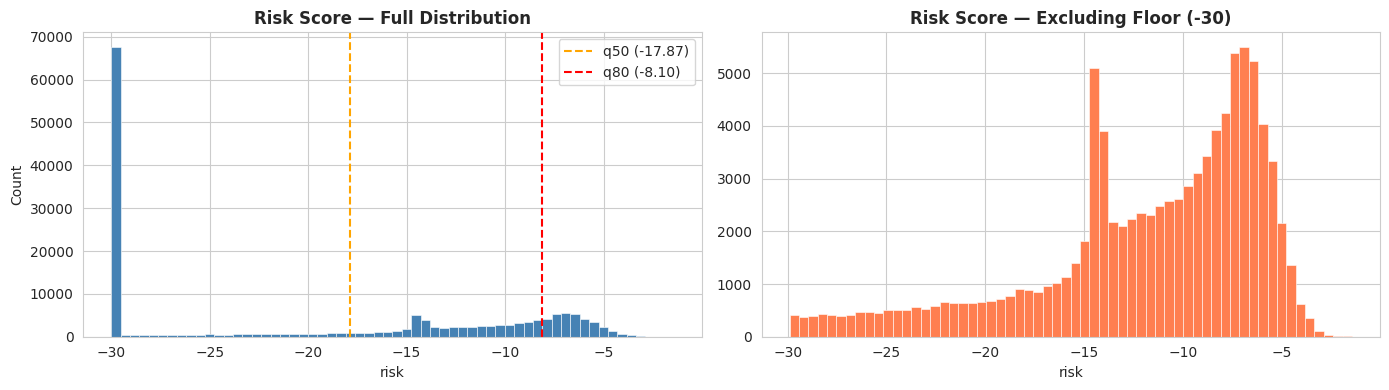

In [4]:
# Visualizing the risk score distribution to understand class imbalance before any processing

print('=== TARGET: risk ===')
print(train_raw['risk'].describe())
print()
print(f'Rows at floor -30       : {(train_raw["risk"] == -30.0).sum():,}  ({(train_raw["risk"] == -30.0).mean()*100:.1f}%)')
print(f'Rows with risk > -10    : {(train_raw["risk"] > -10).sum():,}  ({(train_raw["risk"] > -10).mean()*100:.1f}%)')
print(f'Rows with risk > -5     : {(train_raw["risk"] > -5).sum():,}  ({(train_raw["risk"] > -5).mean()*100:.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train_raw['risk'], bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_title('Risk Score — Full Distribution', fontweight='bold')
axes[0].set_xlabel('risk')
axes[0].set_ylabel('Count')
axes[0].axvline(-17.87, color='orange', linestyle='--', label='q50 (-17.87)')
axes[0].axvline(-8.10,  color='red',    linestyle='--', label='q80 (-8.10)')
axes[0].legend()

non_floor = train_raw[train_raw['risk'] > -29.9]['risk']
axes[1].hist(non_floor, bins=60, color='coral', edgecolor='white', linewidth=0.4)
axes[1].set_title('Risk Score — Excluding Floor (-30)', fontweight='bold')
axes[1].set_xlabel('risk')

plt.tight_layout()
plt.show()

In [5]:
# Each event_id appears multiple times — we must split by group to prevent leakage

print('event_id stats:')
counts = train_raw['event_id'].value_counts()
print(f'  Unique event IDs       : {train_raw["event_id"].nunique():,}')
print(f'  Total rows             : {len(train_raw):,}')
print(f'  Avg rows per event_id  : {counts.mean():.1f}')
print(f'  Max rows per event_id  : {counts.max()}')
print()
print('⚠️  Same event_id appears ~12 times on average.')
print('   If we split randomly, same event appears in both train and validation.')
print('   This inflates scores. We use GroupShuffleSplit to fix this.')

event_id stats:
  Unique event IDs       : 13,154
  Total rows             : 162,634
  Avg rows per event_id  : 12.4
  Max rows per event_id  : 23

⚠️  Same event_id appears ~12 times on average.
   If we split randomly, same event appears in both train and validation.
   This inflates scores. We use GroupShuffleSplit to fix this.


In [6]:
# Separating event_id (for grouping only), features X, and target y — never mix these

TARGET_COL = 'risk'
GROUP_COL  = 'event_id'

# Keep event_id aside for grouping — do NOT include it as a feature
groups = train_raw[GROUP_COL].values

# X = all columns except target and identifier columns
# event_id and mission_id are identifiers, not predictors
X_all = train_raw.drop(columns=[TARGET_COL, 'event_id', 'mission_id'])
y_all = train_raw[TARGET_COL].values

# Test set — same column removal
X_test_raw = test_raw.drop(columns=[c for c in ['event_id', 'mission_id', TARGET_COL]
                                     if c in test_raw.columns])

print(f'X_all shape  : {X_all.shape}')
print(f'y_all shape  : {y_all.shape}')
print(f'Groups shape : {groups.shape}')
print(f'X_test shape : {X_test_raw.shape}')

X_all shape  : (162634, 100)
y_all shape  : (162634,)
Groups shape : (162634,)
X_test shape : (24484, 100)


In [7]:
# Spliting using GroupShuffleSplit so no event_id appears in both train and validation folds

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, val_idx = next(gss.split(X_all, y_all, groups=groups))

X_train = X_all.iloc[train_idx].copy()
X_val   = X_all.iloc[val_idx].copy()
y_train = y_all[train_idx]
y_val   = y_all[val_idx]

groups_train = groups[train_idx]
groups_val   = groups[val_idx]

print(f'Train fold : {X_train.shape[0]:,} rows  |  {X_train["c_object_type"].shape[0]:,} events')
print(f'Val fold   : {X_val.shape[0]:,} rows')
print()

# Verify no event_id overlap between folds
train_events = set(groups_train)
val_events   = set(groups_val)
overlap      = train_events & val_events
print(f'Unique events in train fold : {len(train_events):,}')
print(f'Unique events in val fold   : {len(val_events):,}')
print(f'Event overlap between folds : {len(overlap)}  ← must be 0')

Train fold : 130,596 rows  |  130,596 events
Val fold   : 32,038 rows

Unique events in train fold : 10,523
Unique events in val fold   : 2,631
Event overlap between folds : 0  ← must be 0


In [8]:
# Checking which columns have missing values and how much — on training fold only

missing     = X_train.isnull().sum()
missing_pct = (missing / len(X_train) * 100).round(2)
missing_df  = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df  = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f'Columns with missing values: {len(missing_df)} out of {X_train.shape[1]}')
print()
print(missing_df.to_string())

Columns with missing values: 50 out of 100

                       Missing Count  Missing %
c_rcs_estimate                 42989    32.9200
c_crdot_r                       7243     5.5500
c_cndot_n                       7243     5.5500
c_cndot_rdot                    7243     5.5500
c_cndot_tdot                    7243     5.5500
c_sigma_rdot                    7243     5.5500
c_sigma_ndot                    7243     5.5500
c_sigma_tdot                    7243     5.5500
c_cndot_t                       7243     5.5500
c_cndot_r                       7243     5.5500
c_crdot_t                       7243     5.5500
c_crdot_n                       7243     5.5500
c_ctdot_r                       7243     5.5500
c_ctdot_t                       7243     5.5500
c_ctdot_n                       7243     5.5500
c_ctdot_rdot                    7243     5.5500
t_crdot_r                       7236     5.5400
t_crdot_t                       7236     5.5400
t_sigma_ndot                    7236     5.5

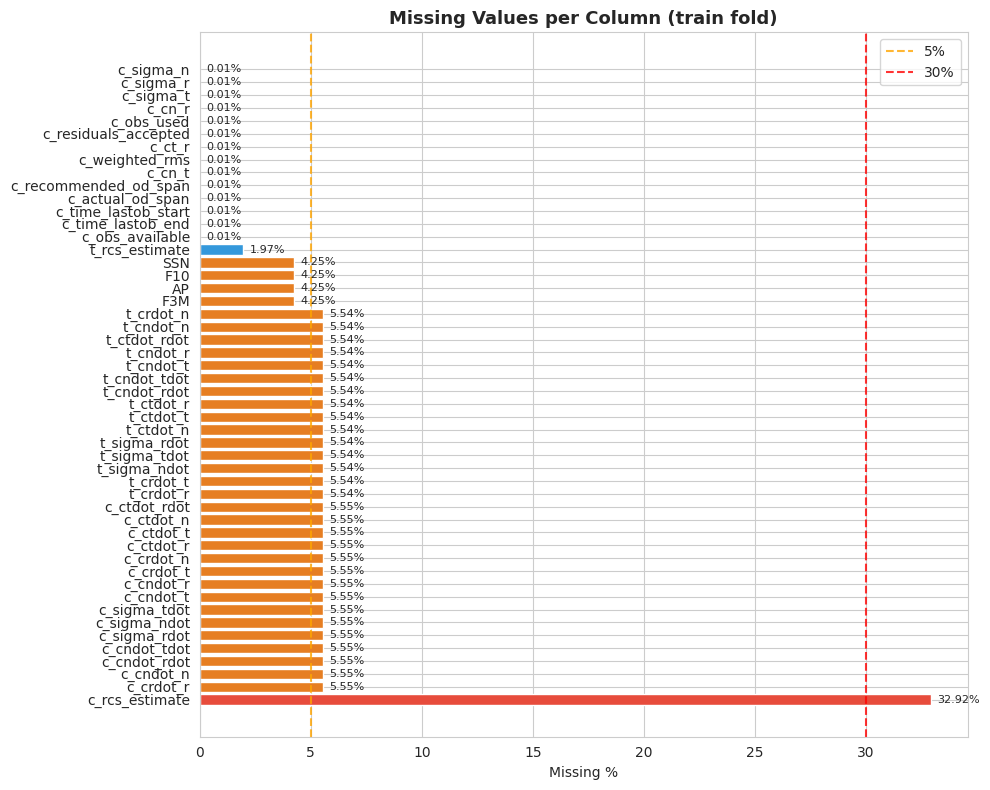

In [9]:
# Visualizing missing percentage per column to understand the scale of the problem

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if p > 20 else '#e67e22' if p > 4 else '#3498db'
          for p in missing_df['Missing %']]
ax.barh(missing_df.index, missing_df['Missing %'], color=colors, edgecolor='white')
ax.axvline(5,  color='orange', linestyle='--', alpha=0.8, label='5%')
ax.axvline(30, color='red',    linestyle='--', alpha=0.8, label='30%')
ax.set_xlabel('Missing %')
ax.set_title('Missing Values per Column (train fold)', fontweight='bold', fontsize=13)
ax.legend()
for i, (idx, row) in enumerate(missing_df.iterrows()):
    ax.text(row['Missing %'] + 0.3, i, f'{row["Missing %"]}%', va='center', fontsize=8)
plt.tight_layout()
plt.show()

In [10]:
# Adding binary flag columns BEFORE imputing so the model knows which values were originally missing

def add_flags(df):
    df = df.copy()
    # c_rcs_estimate missing 32.5% — debris often has no radar cross-section
    df['flag_c_rcs_missing']    = df['c_rcs_estimate'].isnull().astype(int)
    # t_rcs_estimate missing 2%
    df['flag_t_rcs_missing']    = df['t_rcs_estimate'].isnull().astype(int)
    # Velocity covariance dot-block all missing together at 5.68%
    df['flag_cov_block_missing'] = df['t_crdot_r'].isnull().astype(int)
    # Solar weather indices F10 F3M SSN AP missing together at 4.19%
    df['flag_solar_missing']    = df['F10'].isnull().astype(int)
    return df

X_train    = add_flags(X_train)
X_val      = add_flags(X_val)
X_test_raw = add_flags(X_test_raw)

flag_cols = ['flag_c_rcs_missing', 'flag_t_rcs_missing',
             'flag_cov_block_missing', 'flag_solar_missing']

print('✅ Missingness flags added to train, val, and test:')
for f in flag_cols:
    print(f'  {f:<30} : {X_train[f].sum():>7,} rows flagged in train fold')

✅ Missingness flags added to train, val, and test:
  flag_c_rcs_missing             :  42,989 rows flagged in train fold
  flag_t_rcs_missing             :   2,574 rows flagged in train fold
  flag_cov_block_missing         :   7,236 rows flagged in train fold
  flag_solar_missing             :   5,549 rows flagged in train fold


In [11]:
# One-hot encode c_object_type before imputation so all columns are numeric for the imputer

def encode_object_type(df_train, df_val, df_test):
    df_train = pd.get_dummies(df_train, columns=['c_object_type'], prefix='obj', dtype=int)
    df_val   = pd.get_dummies(df_val,   columns=['c_object_type'], prefix='obj', dtype=int)
    df_test  = pd.get_dummies(df_test,  columns=['c_object_type'], prefix='obj', dtype=int)

    # Align val and test to train columns — add 0 for any missing category
    for col in df_train.columns:
        if col.startswith('obj_'):
            if col not in df_val.columns:   df_val[col]  = 0
            if col not in df_test.columns:  df_test[col] = 0

    return df_train, df_val, df_test

X_train, X_val, X_test_raw = encode_object_type(X_train, X_val, X_test_raw)

obj_cols = [c for c in X_train.columns if c.startswith('obj_')]
print('✅ One-hot encoding done. New columns:', obj_cols)
print(f'   X_train: {X_train.shape}  |  X_val: {X_val.shape}  |  X_test: {X_test_raw.shape}')

✅ One-hot encoding done. New columns: ['obj_DEBRIS', 'obj_PAYLOAD', 'obj_ROCKET BODY', 'obj_TBA', 'obj_UNKNOWN']
   X_train: (130596, 108)  |  X_val: (32038, 108)  |  X_test: (24484, 108)


In [12]:
# Fitting imputer ONLY on training fold — then apply same fitted imputer to val and test

skip_impute = flag_cols + obj_cols

num_cols_to_impute = [
    c for c in X_train.select_dtypes(include='number').columns
    if c not in skip_impute
]

# Fit on train fold only
imputer = SimpleImputer(strategy='median')
X_train[num_cols_to_impute] = imputer.fit_transform(X_train[num_cols_to_impute])

# Transform val and test using the same fitted imputer — no refitting
X_val[num_cols_to_impute]         = imputer.transform(X_val[num_cols_to_impute])
X_test_raw[num_cols_to_impute]    = imputer.transform(X_test_raw[num_cols_to_impute])

print('✅ Median imputer fit on train fold only — applied to val and test')
print(f'   Missing in X_train : {X_train.isnull().sum().sum()}')
print(f'   Missing in X_val   : {X_val.isnull().sum().sum()}')
print(f'   Missing in X_test  : {X_test_raw.isnull().sum().sum()}')

✅ Median imputer fit on train fold only — applied to val and test
   Missing in X_train : 0
   Missing in X_val   : 0
   Missing in X_test  : 0


In [13]:
# Applying log1p to heavily skewed columns that are strictly positive to reduce outlier effect

skip_log = flag_cols + obj_cols

feature_cols = [c for c in X_train.select_dtypes(include='number').columns
                if c not in skip_log]

skew_series = X_train[feature_cols].skew().abs()

SKEW_THRESHOLD = 1.0

# Only apply where ALL values are strictly positive across train, val, and test
log_cols = [
    c for c in skew_series[skew_series > SKEW_THRESHOLD].index
    if (X_train[c] > 0).all() and (X_val[c] > 0).all() and (X_test_raw[c] > 0).all()
]

X_train[log_cols]    = np.log1p(X_train[log_cols])
X_val[log_cols]      = np.log1p(X_val[log_cols])
X_test_raw[log_cols] = np.log1p(X_test_raw[log_cols])

print(f'✅ log1p applied to {len(log_cols)} skewed columns')
print(log_cols)

✅ log1p applied to 35 skewed columns
['max_risk_scaling', 't_time_lastob_start', 't_recommended_od_span', 't_obs_available', 't_obs_used', 't_residuals_accepted', 't_rcs_estimate', 't_j2k_ecc', 'c_time_lastob_start', 'c_obs_available', 'c_obs_used', 'c_residuals_accepted', 'c_weighted_rms', 'c_rcs_estimate', 'c_j2k_sma', 'c_j2k_ecc', 'c_j2k_inc', 'c_span', 'c_h_apo', 'mahalanobis_distance', 't_position_covariance_det', 't_sigma_r', 'c_sigma_r', 't_sigma_t', 'c_sigma_t', 't_sigma_n', 'c_sigma_n', 't_sigma_rdot', 'c_sigma_rdot', 't_sigma_tdot', 'c_sigma_tdot', 't_sigma_ndot', 'c_sigma_ndot', 'F10', 'F3M']


In [14]:
# Fitting RobustScaler on train fold only — then apply same scaler to val and test

skip_scaling = flag_cols + obj_cols

scale_cols = [c for c in X_train.select_dtypes(include='number').columns
              if c not in skip_scaling]

scaler = RobustScaler()

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])

X_val[scale_cols]         = scaler.transform(X_val[scale_cols])
X_test_raw[scale_cols]    = scaler.transform(X_test_raw[scale_cols])

print('✅ RobustScaler fit on train fold — applied to val and test')
print(f'   Columns scaled : {len(scale_cols)}')

✅ RobustScaler fit on train fold — applied to val and test
   Columns scaled : 99


In [15]:
# Confirming scaled columns are centered near 0 with reasonable spread

print('Sample scaled column statistics (should be near 0 center):')
X_train[scale_cols[:6]].describe().loc[['mean', 'std', 'min', 'max']].round(3)

Sample scaled column statistics (should be near 0 center):


,time_to_tca,max_risk_estimate,max_risk_scaling,miss_distance,relative_speed,relative_position_r
mean,0.0140,0.0320,0.2000,0.1970,-0.2310,-0.0250
std,0.5760,0.7290,0.8330,0.6900,0.6160,1.1990
min,-0.9880,-2.5170,-1.0040,-0.6030,-1.7540,-8.8910
max,1.0550,3.7840,4.0960,2.6610,0.6800,9.8590


Data-driven thresholds (from train fold only):
  q50 = -17.8901  → Low    : risk <= -17.8901
  q80 = -8.0989  → Medium : -17.8901 < risk <= -8.0989
                    → High   : risk > -8.0989

Class distribution in train fold:
  Class 0 (Low    ):  65,299  ( 50.0%)  ████████████████████
  Class 1 (Medium ):  39,179  ( 30.0%)  ████████████
  Class 2 (High   ):  26,118  ( 20.0%)  ███████

Class distribution in val fold:
  Class 0 (Low    ):  15,982  ( 49.9%)
  Class 1 (Medium ):   9,638  ( 30.1%)
  Class 2 (High   ):   6,418  ( 20.0%)


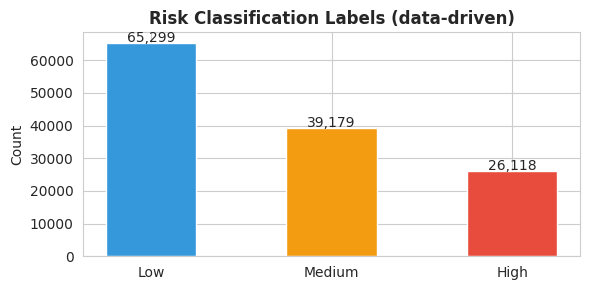

In [16]:
# Creating risk_label using quantiles from training fold ONLY — not arbitrary thresholds

# Compute thresholds from y_train only
q50 = np.quantile(y_train, 0.50)
q80 = np.quantile(y_train, 0.80)

print(f'Data-driven thresholds (from train fold only):')
print(f'  q50 = {q50:.4f}  → Low    : risk <= {q50:.4f}')
print(f'  q80 = {q80:.4f}  → Medium : {q50:.4f} < risk <= {q80:.4f}')
print(f'                    → High   : risk > {q80:.4f}')

def make_labels(y, q1, q2):
    labels = np.zeros(len(y), dtype=int)
    labels[y > q1] = 1
    labels[y > q2] = 2
    return labels

y_train_label = make_labels(y_train, q50, q80)
y_val_label   = make_labels(y_val,   q50, q80)  # same thresholds from train

label_names  = {0: 'Low', 1: 'Medium', 2: 'High'}

print()
print('Class distribution in train fold:')
for lbl in [0, 1, 2]:
    cnt = (y_train_label == lbl).sum()
    bar = '█' * int(cnt / len(y_train_label) * 40)
    print(f'  Class {lbl} ({label_names[lbl]:<7}): {cnt:>7,}  ({cnt/len(y_train_label)*100:5.1f}%)  {bar}')

print()
print('Class distribution in val fold:')
for lbl in [0, 1, 2]:
    cnt = (y_val_label == lbl).sum()
    print(f'  Class {lbl} ({label_names[lbl]:<7}): {cnt:>7,}  ({cnt/len(y_val_label)*100:5.1f}%)')

fig, ax = plt.subplots(figsize=(6, 3))
colors = ['#3498db', '#f39c12', '#e74c3c']
unique, cnts = np.unique(y_train_label, return_counts=True)
bars = ax.bar([label_names[l] for l in unique], cnts, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, cnts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{val:,}', ha='center', fontsize=10)
ax.set_title('Risk Classification Labels (data-driven)', fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [17]:
# Saving all processed splits as CSV files ready for modelling

# Add targets back for saving
train_out = X_train.copy()
train_out['risk']       = y_train
train_out['risk_label'] = y_train_label

val_out = X_val.copy()
val_out['risk']       = y_val
val_out['risk_label'] = y_val_label

train_out.to_csv('train_processed.csv', index=False)
val_out.to_csv('val_processed.csv',     index=False)
X_test_raw.to_csv('test_processed.csv', index=False)

# Save thresholds so your friend uses the same ones
import json
thresholds = {'q50': float(q50), 'q80': float(q80)}
with open('label_thresholds.json', 'w') as f:
    json.dump(thresholds, f)

print('✅ Files saved:')
print(f'   train_processed.csv    → {train_out.shape}  (has risk + risk_label)')
print(f'   val_processed.csv      → {val_out.shape}  (has risk + risk_label)')
print(f'   test_processed.csv     → {X_test_raw.shape}  (features only)')
print(f'   label_thresholds.json  → q50={q50:.4f}, q80={q80:.4f}')

✅ Files saved:
   train_processed.csv    → (130596, 110)  (has risk + risk_label)
   val_processed.csv      → (32038, 110)  (has risk + risk_label)
   test_processed.csv     → (24484, 108)  (features only)
   label_thresholds.json  → q50=-17.8901, q80=-8.0989


In [18]:
# Downloading all processed files.

from google.colab import files

files.download('train_processed.csv')
files.download('val_processed.csv')
files.download('test_processed.csv')
files.download('label_thresholds.json')

print('📥 Downloads started!')
print()
print('  train_processed.csv   — training data with risk + risk_label')
print('  val_processed.csv     — validation data with risk + risk_label')
print('  test_processed.csv    — test features for final prediction')
print('  label_thresholds.json — q50 and q80 used to create labels')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Downloads started!

  train_processed.csv   — training data with risk + risk_label
  val_processed.csv     — validation data with risk + risk_label
  test_processed.csv    — test features for final prediction
  label_thresholds.json — q50 and q80 used to create labels
